2024-10-10 14:31:18: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2024-10-10 14:31:18: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2024-10-10 14:31:18: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2024-10-10 14:31:18: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2024-10-10 14:31:18: oggm.workflow: Execute entity tasks [GlacierDirectory] on 1 glaciers
2024-10-10 14:31:18: oggm.workflow: Execute entity tasks [GlacierDirectory] on 1 glaciers


AttributeError: 'QuadMesh' object has no attribute 'collections'

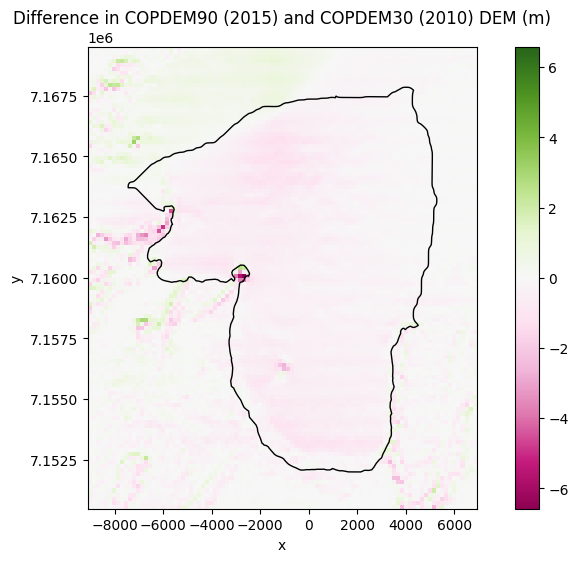

In [12]:
import rioxarray as rioxr  
import matplotlib.pyplot as plt  
import oggm  
from oggm import cfg, utils, workflow, tasks  

# Initialize OGGM  
cfg.initialize(logging_level='WARNING')  
cfg.PARAMS['border'] = 10  

# Get glacier entity  
entity = utils.get_rgi_glacier_entities(['RGI60-06.00291'])  

# Create a working directory for DEMs  
cfg.PATHS['working_dir'] = utils.gettempdir('default', reset=True)  

# Initialize glacier directories for the first DEM  
gdir1 = workflow.init_glacier_directories(entity)[0]  
tasks.define_glacier_region(gdir1, source='COPDEM30')  # First DEM source  
dem_path1 = gdir1.get_filepath('dem')  
da1 = rioxr.open_rasterio(dem_path1)  

# Initialize glacier directories for the second DEM  
gdir2 = workflow.init_glacier_directories(entity)[0]  
tasks.define_glacier_region(gdir2, source='COPDEM90')  # Replace with actual second DEM source  
dem_path2 = gdir2.get_filepath('dem')  
da2 = rioxr.open_rasterio(dem_path2)  

# Check if both DataArrays have the same shape  
if da1.shape != da2.shape:  
    raise ValueError("The two DEMs do not have the same shape. Please align or resample them.")  

# Calculate the difference between the two DEMs  
da_diff = da2 - da1  

# Plot the difference  
f, ax = plt.subplots(1, 1, figsize=(10, 6))  
quadmesh = da_diff.plot(cmap='PiYG', ax=ax)  # Do not set title here  
ax.set_title('Difference in COPDEM90 (2015) and COPDEM30 (2010) DEM (m)')          # Set title using ax.set_title()  

# Add outlines for visualization  
gdir1.read_shapefile('outlines').plot(ax=ax, color='none', edgecolor='black')  

# Add a colorbar to show altitude difference  
plt.colorbar(quadmesh.collections[0], ax=ax, label='Altitude Difference (m)')  # Adjust colorbar reference if necessary  

# Show the plot  
plt.show()